# 📊 Step 4 — Evaluation & Results

**Protein Function Prediction Using Genomic Language Model (ESM-2)**

Comprehensive evaluation on the test set with results output as **tables, graphs, and JSON**.

---

### Output Files
| File | Format | Description |
|------|--------|-------------|
| `results/metrics/evaluation_report.json` | JSON | All computed metrics |
| `results/metrics/per_class_metrics.csv` | Table | Per-GO-term F1, precision, recall, AP |
| `results/metrics/summary_table.csv` | Table | Global metrics summary |
| `results/plots/roc_curves.png` | Graph | Per-class ROC curves |
| `results/plots/precision_recall_curves.png` | Graph | Per-class PR curves |
| `results/plots/per_class_f1.png` | Graph | F1 ranking bar chart |
| `results/plots/confusion_heatmap.png` | Graph | Multi-label confusion |
| `results/plots/prediction_distribution.png` | Graph | Confidence histograms |

In [3]:
import os, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    average_precision_score, hamming_loss, roc_curve, auc,
    precision_recall_curve,
)

# ─── Configuration ───
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_ROOT, 'results', 'metrics')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'plots')
for d in [METRICS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

EMBEDDING_DIM = 320
HIDDEN_DIMS = [512, 256]
DROPOUT = 0.3
BATCH_SIZE = 32
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A855F7', '#F97316', '#06B6D4', '#EC4899']

print(f'🖥️  Device: {DEVICE}')

🖥️  Device: cpu


## 4.1 — Load Model & Data

In [4]:
# ─── Inline model classes (same as 03_train) ───
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.skip = (in_dim == out_dim)
        self.block = nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x):
        out = self.block(x)
        return out + x if self.skip else out

class ProteinFunctionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_labels, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(ResidualBlock(prev, h, dropout)); prev = h
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev, num_labels)
    def forward(self, x): return self.classifier(self.features(x))
    def predict_proba(self, x): return torch.sigmoid(self.forward(x))

class ProteinDataset(Dataset):
    def __init__(self, emb, lab): self.X, self.y = torch.FloatTensor(emb), torch.FloatTensor(lab)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# Load checkpoint
ckpt = torch.load(os.path.join(MODELS_DIR, 'best_model.pt'), map_location=DEVICE, weights_only=False)
cfg = ckpt['config']
model = ProteinFunctionClassifier(cfg['input_dim'], cfg['hidden_dims'], cfg['num_labels'], cfg['dropout']).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'✅ Model loaded (epoch {ckpt["epoch"]}, F1µ={ckpt["val_f1"]:.4f})')

# Load label binarizer
with open(os.path.join(PROCESSED_DIR, 'label_binarizer.pkl'), 'rb') as f:
    mlb = pickle.load(f)
go_terms = mlb.classes_

# Load test data
X_test = np.load(os.path.join(PROCESSED_DIR, 'embeddings_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'labels_test.npy'))
print(f'📊 Test: {X_test.shape}, Labels: {y_test.shape}')

✅ Model loaded (epoch 3, F1µ=0.7143)
📊 Test: (8, 320), Labels: (8, 4)


## 4.2 — Generate Test Predictions

In [5]:
loader = DataLoader(ProteinDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
all_probs = []
with torch.no_grad():
    for xb, _ in loader:
        all_probs.append(model.predict_proba(xb.to(DEVICE)).cpu().numpy())
y_probs = np.concatenate(all_probs)
y_pred = (y_probs >= 0.5).astype(int)
y_true = y_test
print(f'✅ Predictions: {y_probs.shape}')

✅ Predictions: (8, 4)


## 4.3 — 📋 Results: Global Metrics (JSON + Table)

In [6]:
metrics = {
    'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
    'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
    'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
    'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
    'hamming_loss': hamming_loss(y_true, y_pred),
    'accuracy': 1.0 - hamming_loss(y_true, y_pred),
    'subset_accuracy': float((y_pred == y_true).all(axis=1).mean()),
    'total_test_samples': int(len(y_true)),
    'num_labels': int(y_true.shape[1]),
}
try:
    metrics['auroc_micro'] = roc_auc_score(y_true, y_probs, average='micro')
    metrics['auroc_macro'] = roc_auc_score(y_true, y_probs, average='macro')
except:
    metrics['auroc_micro'] = metrics['auroc_macro'] = 0.0

# Mean average precision
aps = [average_precision_score(y_true[:, i], y_probs[:, i]) if y_true[:, i].sum() > 0 else 0.0
       for i in range(y_true.shape[1])]
metrics['mean_average_precision'] = float(np.mean(aps))

# ─── Save as JSON ───
json_path = os.path.join(METRICS_DIR, 'evaluation_report.json')
with open(json_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'💾 JSON → {json_path}')

# ─── Save as CSV Table ───
summary_df = pd.DataFrame([
    {'Metric': k, 'Value': f'{v:.4f}' if isinstance(v, float) else str(v)}
    for k, v in metrics.items()
])
csv_path = os.path.join(METRICS_DIR, 'summary_table.csv')
summary_df.to_csv(csv_path, index=False)
print(f'💾 CSV → {csv_path}')

# ─── Display ───
print(f'\n{"═"*50}')
print(f'{"TEST SET RESULTS":^50}')
print(f'{"═"*50}')
for k, v in metrics.items():
    print(f'  {k:25s}: {v:.4f}' if isinstance(v, float) else f'  {k:25s}: {v}')
print(f'{"═"*50}')
summary_df

💾 JSON → c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\evaluation_report.json
💾 CSV → c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\summary_table.csv

══════════════════════════════════════════════════
                 TEST SET RESULTS                 
══════════════════════════════════════════════════
  f1_micro                 : 0.5161
  f1_macro                 : 0.4485
  f1_weighted              : 0.5446
  precision_micro          : 0.4706
  precision_macro          : 0.4464
  recall_micro             : 0.5714
  recall_macro             : 0.5595
  hamming_loss             : 0.4688
  accuracy                 : 0.5312
  subset_accuracy          : 0.0000
  total_test_samples       : 8
  num_labels               : 4
  auroc_micro              : 0.5556
  auroc_macro              : 0.6667
  mean_average_precision   : 0.5590
══════════════════════════════════════════════════


,Metric,Value
0,f1_micro,0.5161
1,f1_macro,0.4485
2,f1_weighted,0.5446
3,precision_micro,0.4706
4,precision_macro,0.4464
5,recall_micro,0.5714
6,recall_macro,0.5595
7,hamming_loss,0.4688
8,accuracy,0.5312
9,subset_accuracy,0.0000


## 4.4 — 📋 Results: Per-Class Metrics (CSV Table + JSON)

In [7]:
per_class = pd.DataFrame({
    'go_term': go_terms,
    'f1_score': f1_score(y_true, y_pred, average=None, zero_division=0),
    'precision': precision_score(y_true, y_pred, average=None, zero_division=0),
    'recall': recall_score(y_true, y_pred, average=None, zero_division=0),
    'avg_precision': aps,
    'support': y_true.sum(axis=0).astype(int),
}).sort_values('f1_score', ascending=False)

# Save as CSV
pc_csv = os.path.join(METRICS_DIR, 'per_class_metrics.csv')
per_class.to_csv(pc_csv, index=False)
print(f'💾 Per-class CSV → {pc_csv}')

# Save as JSON
pc_json = os.path.join(METRICS_DIR, 'per_class_metrics.json')
per_class.to_json(pc_json, orient='records', indent=2)
print(f'💾 Per-class JSON → {pc_json}')

print(f'\n📊 Per-Class Metrics (sorted by F1):')
per_class.head(20)

💾 Per-class CSV → c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\per_class_metrics.csv
💾 Per-class JSON → c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\per_class_metrics.json

📊 Per-Class Metrics (sorted by F1):


,go_term,f1_score,precision,recall,avg_precision,support
1,GO:0005737,0.727273,1.000000,0.571429,1.000000,7
3,GO:0005886,0.666667,0.500000,1.000000,0.500000,2
2,GO:0005829,0.400000,0.285714,0.666667,0.369444,3
0,GO:0005634,0.000000,0.000000,0.000000,0.366667,2


## 4.5 — 📈 Graph: ROC Curves

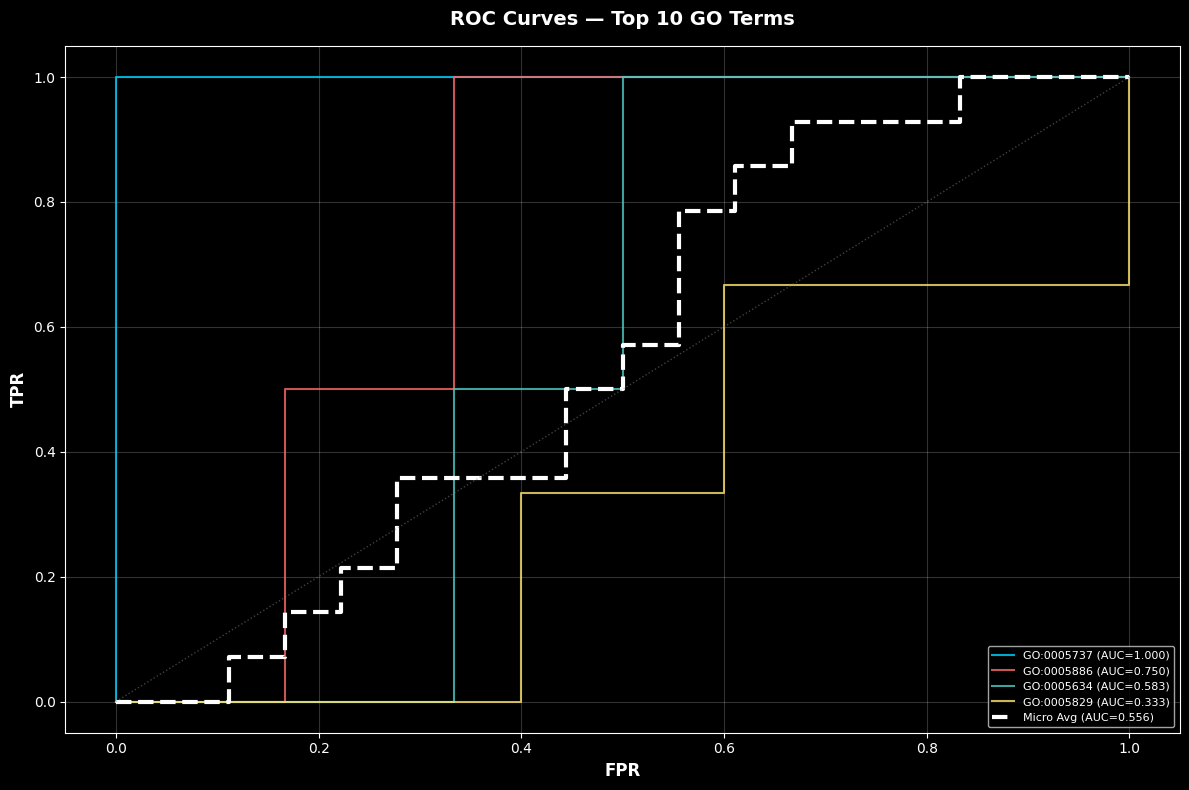

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
auroc_list = []
for i in range(y_true.shape[1]):
    if y_true[:, i].sum() > 0 and y_true[:, i].sum() < len(y_true):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
        auroc_list.append((i, auc(fpr, tpr), fpr, tpr))
auroc_list.sort(key=lambda x: x[1], reverse=True)

for rank, (idx, a, fpr, tpr) in enumerate(auroc_list[:10]):
    ax.plot(fpr, tpr, color=COLORS[rank % len(COLORS)], lw=1.5, alpha=0.8,
            label=f'{go_terms[idx]} (AUC={a:.3f})')

fpr_m, tpr_m, _ = roc_curve(y_true.ravel(), y_probs.ravel())
ax.plot(fpr_m, tpr_m, 'w--', lw=3, label=f'Micro Avg (AUC={auc(fpr_m, tpr_m):.3f})')
ax.plot([0,1],[0,1], 'gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('FPR', fontsize=12, fontweight='bold')
ax.set_ylabel('TPR', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves — Top 10 GO Terms', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4.6 — 📈 Graph: Precision-Recall Curves

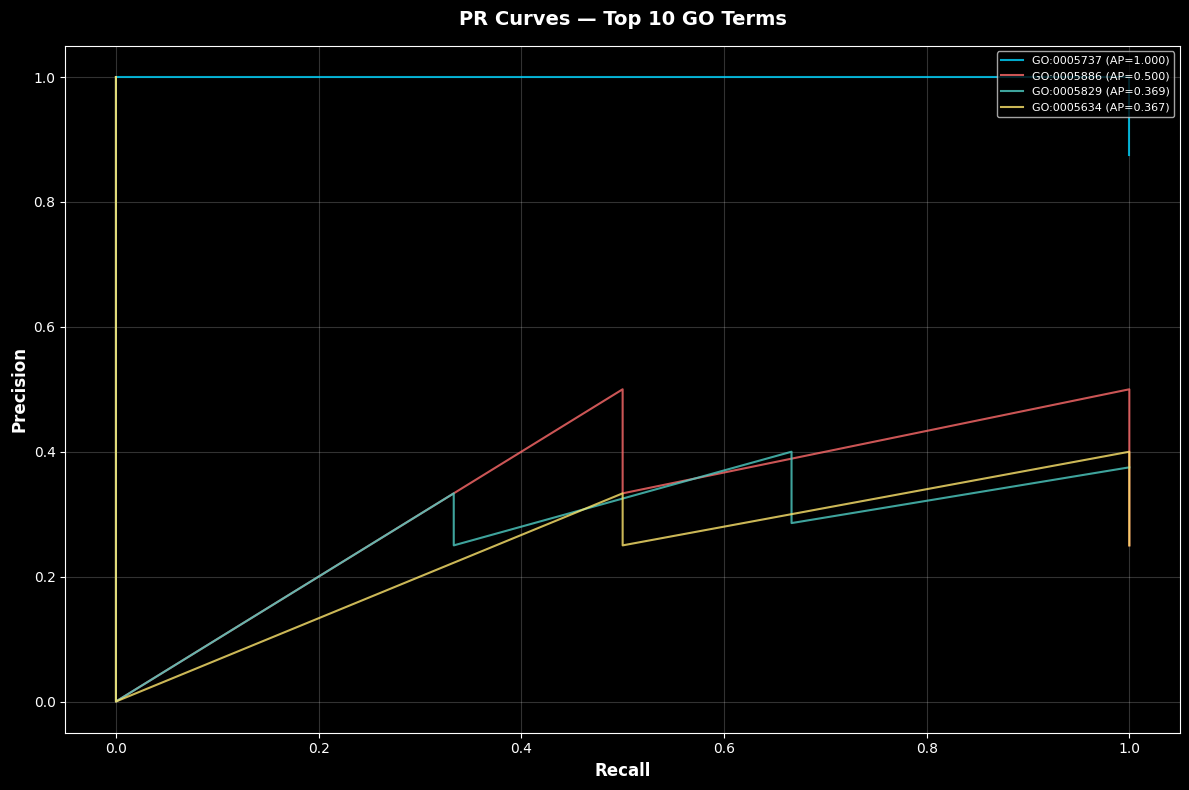

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
pr_list = []
for i in range(y_true.shape[1]):
    if y_true[:, i].sum() > 0:
        p, r, _ = precision_recall_curve(y_true[:, i], y_probs[:, i])
        pr_list.append((i, aps[i], p, r))
pr_list.sort(key=lambda x: x[1], reverse=True)

for rank, (idx, ap, p, r) in enumerate(pr_list[:10]):
    ax.plot(r, p, color=COLORS[rank % len(COLORS)], lw=1.5, alpha=0.8,
            label=f'{go_terms[idx]} (AP={ap:.3f})')
ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('PR Curves — Top 10 GO Terms', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'precision_recall_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4.7 — 📈 Graph: Per-Class F1 Ranking

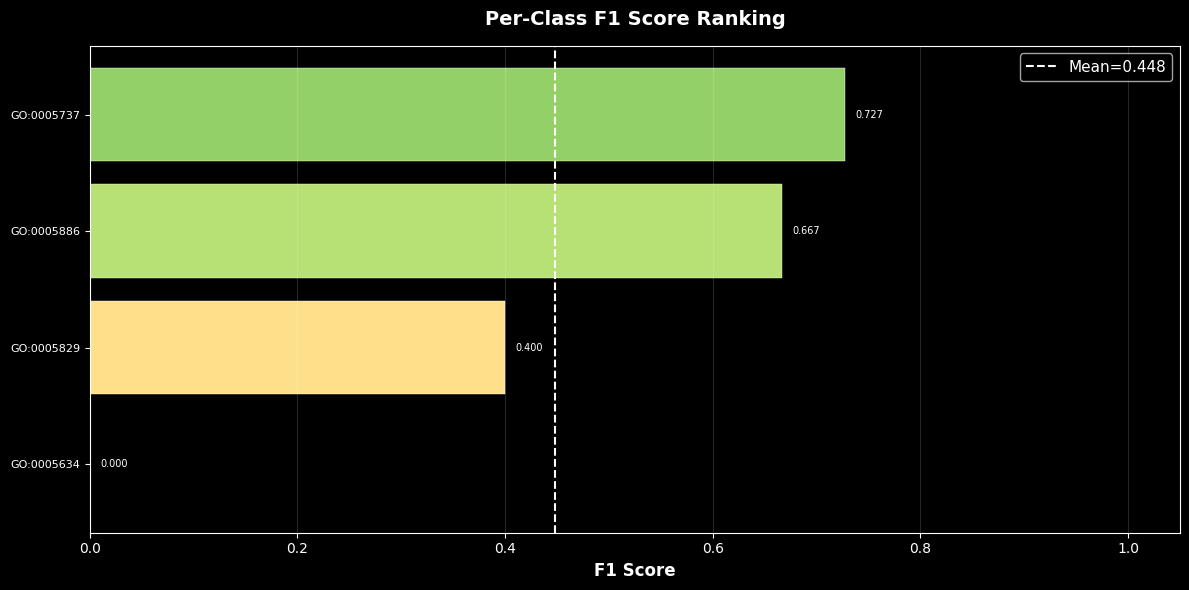

In [8]:
pcf1 = per_class.sort_values('f1_score')
fig, ax = plt.subplots(figsize=(12, max(6, len(pcf1) * 0.35)))
bar_colors = plt.cm.RdYlGn(pcf1['f1_score'].values)
ax.barh(range(len(pcf1)), pcf1['f1_score'].values, color=bar_colors, edgecolor='white', lw=0.3, height=0.8)
ax.set_yticks(range(len(pcf1))); ax.set_yticklabels(pcf1['go_term'].values, fontsize=8)
ax.set_xlabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Score Ranking', fontsize=14, fontweight='bold', pad=15)
mean_f1 = pcf1['f1_score'].mean()
ax.axvline(mean_f1, color='white', ls='--', lw=1.5, label=f'Mean={mean_f1:.3f}')
ax.legend(fontsize=11); ax.set_xlim([0, 1.05]); ax.grid(True, alpha=0.15, axis='x')
for i, v in enumerate(pcf1['f1_score'].values):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=7, color='white')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'per_class_f1.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4.8 — 📈 Graph: Confusion Heatmap

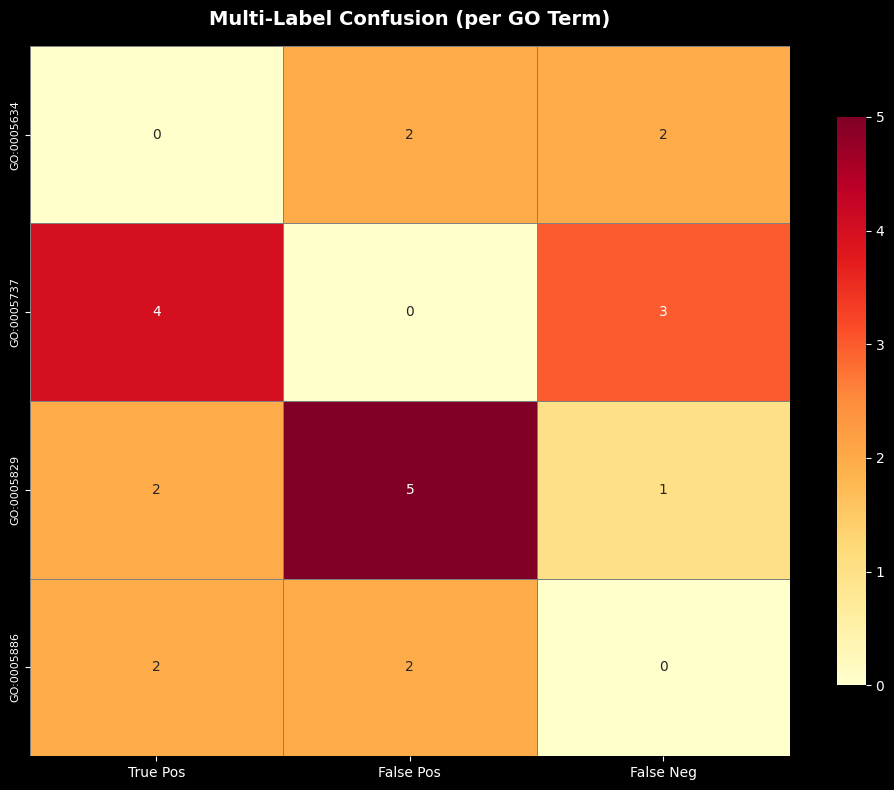

In [9]:
tp = ((y_pred == 1) & (y_true == 1)).sum(axis=0)
fp = ((y_pred == 1) & (y_true == 0)).sum(axis=0)
fn = ((y_pred == 0) & (y_true == 1)).sum(axis=0)
conf_df = pd.DataFrame({'True Pos': tp, 'False Pos': fp, 'False Neg': fn}, index=go_terms)

fig, ax = plt.subplots(figsize=(10, max(8, len(go_terms) * 0.35)))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            cbar_kws={'shrink': 0.8}, linewidths=0.5, linecolor='gray')
ax.set_title('Multi-Label Confusion (per GO Term)', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4.9 — 📈 Graph: Prediction Probability Distribution

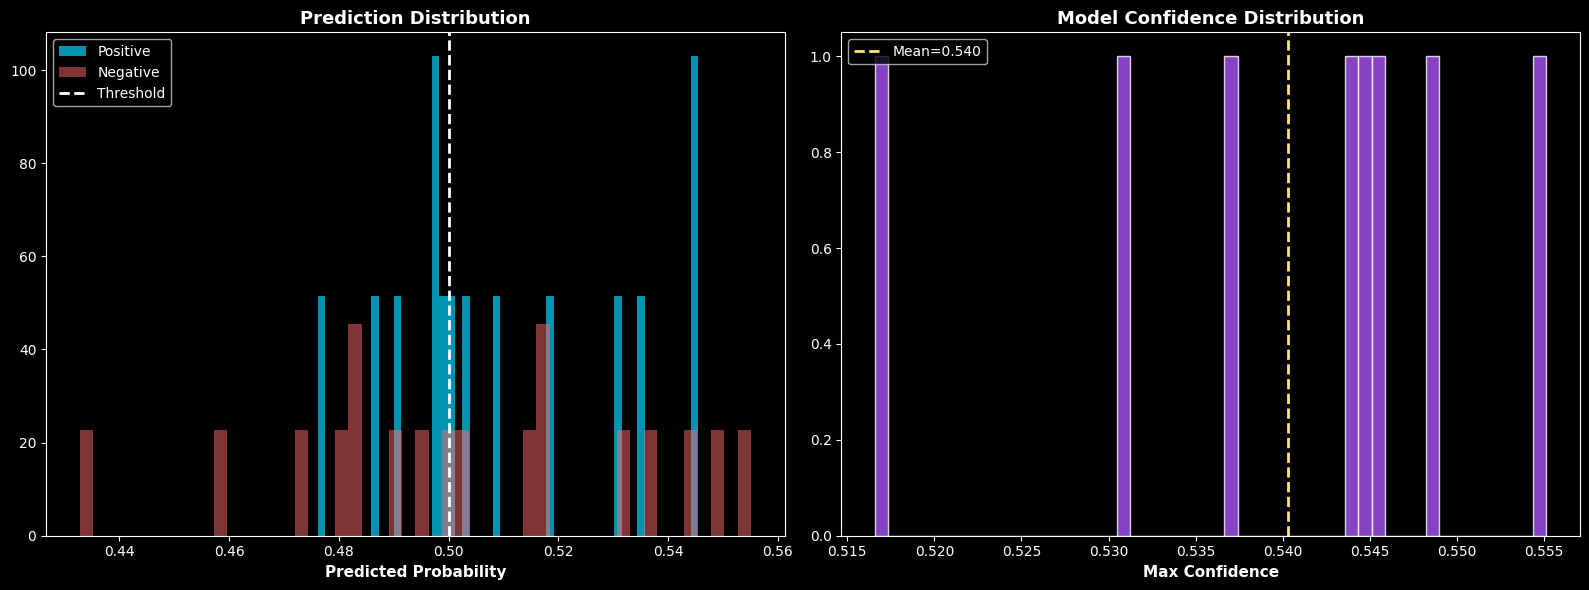

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive vs Negative
ax = axes[0]
pos_mask = y_true == 1; neg_mask = y_true == 0
ax.hist(y_probs[pos_mask].flatten(), bins=50, color=COLORS[0], alpha=0.7, density=True, label='Positive')
ax.hist(y_probs[neg_mask].flatten(), bins=50, color=COLORS[1], alpha=0.5, density=True, label='Negative')
ax.axvline(0.5, color='white', ls='--', lw=2, label='Threshold')
ax.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax.set_title('Prediction Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Max confidence per sample
ax = axes[1]
max_conf = y_probs.max(axis=1)
ax.hist(max_conf, bins=50, color=COLORS[4], alpha=0.8, edgecolor='white')
ax.axvline(max_conf.mean(), color=COLORS[3], ls='--', lw=2, label=f'Mean={max_conf.mean():.3f}')
ax.set_xlabel('Max Confidence', fontsize=11, fontweight='bold')
ax.set_title('Model Confidence Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'prediction_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4.10 — Results Summary

All results have been saved in three formats:

In [11]:
print('\n' + '='*60)
print('  RESULTS OUTPUT SUMMARY')
print('='*60)
print(f'\n📋 TABLES (CSV):')
print(f'   • {csv_path}')
print(f'   • {pc_csv}')
print(f'\n📊 GRAPHS (PNG @ 300 DPI):')
for p in ['roc_curves.png', 'precision_recall_curves.png', 'per_class_f1.png',
          'confusion_heatmap.png', 'prediction_distribution.png']:
    print(f'   • {os.path.join(PLOTS_DIR, p)}')
print(f'\n📄 JSON:')
print(f'   • {json_path}')
print(f'   • {pc_json}')
print('\n' + '='*60)


  RESULTS OUTPUT SUMMARY

📋 TABLES (CSV):
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\summary_table.csv
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\per_class_metrics.csv

📊 GRAPHS (PNG @ 300 DPI):
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\plots\roc_curves.png
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\plots\precision_recall_curves.png
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\plots\per_class_f1.png
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\plots\confusion_heatmap.png
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\plots\prediction_distribution.png

📄 JSON:
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\evaluation_report.json
   • c:\Users\chowd\OneDrive\Desktop\Work_ML\p

---
### ✅ Evaluation & Results Complete!
**Next →** Open `05_predict.ipynb` for inference on new sequences, or `06_visualize.ipynb` for advanced plots.